<a href="https://colab.research.google.com/github/Lucas66666677/Hand-wrting-recognization-System-CN-/blob/main/AI%E6%89%8B%E5%AF%AB%E8%BE%A8%E8%AD%98%E7%B3%BB%E7%B5%B1%E5%96%AE%E5%80%8B%E6%95%B8%E5%AD%97CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 個人化AI手寫辨識系統 ##

## 1. 讀入套件



In [56]:
!pip install gradio

In [57]:
%matplotlib inline

# 必要套件匯入（固定4行套件）
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# 神經網路相關套件
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 其他輔助套件
from ipywidgets import interact_manual
import gradio as gr
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [58]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [59]:
print(f'訓練資料總筆數為 {len(x_train)} 筆資料')
print(f'測試資料總筆數為 {len(x_test)} 筆資料')

訓練資料總筆數為 60000 筆資料
測試資料總筆數為 10000 筆資料


In [60]:
def show_xy(n=0):
    ax = plt.gca()
    X = x_train[n]
    plt.xticks([], [])
    plt.yticks([], [])
    plt.imshow(X, cmap = 'Greys')
    print(f'本資料 y 給定的答案為: {y_train[n]}')

In [61]:
interact_manual(show_xy, n=(0,59999));

interactive(children=(IntSlider(value=0, description='n', max=59999), Button(description='Run Interact', style…

### 用 `reshape` 調校一下。輸入格式整理


In [62]:
# 將資料塑形成 CNN 需要的格式：(筆數, 長, 寬, 通道數)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# 標籤 One-hot encoding 保持不變
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [63]:
# 檢視標籤編碼
n = 87
print(f"第{n}筆資料標籤: {y_train[n]}")

第87筆資料標籤: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## 2. 建構5層神經網路


In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [65]:
# 建立5層Sequential模型
model = Sequential()

In [66]:
# 第1層卷積層：提取邊緣特徵
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(BatchNormalization())

In [67]:
# 第2層卷積層：提取更複雜的特徵
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())

In [68]:
# 池化層：縮小圖片尺寸，保留重要特徵，這是對抗「平移/縮放」的關鍵
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

In [69]:
# 攤平層：準備進入分類器
model.add(Flatten())

In [70]:
# 全連接層 (DNN)
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

In [71]:
# 輸出層
model.add(Dense(10, activation='softmax'))

In [72]:
# 編譯模型
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

## 4. 檢視我們的神經網路

In [73]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,266 (4.58 MB)

 Trainable params: 1,200,074 (4.58 MB)

 Non-trainable params: 192 (768.00 B)

## 5.訓練神經網路

In [74]:
# 計算參數總數
total_params = model.count_params()
print(f"總參數數量: {total_params:,}")

總參數數量: 1,200,266


In [75]:
# 設定回調函數 (加強訓練效果)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [76]:
# 訓練模型 (加入驗證集監控)
print("開始訓練5層神經網路...")
history = model.fit(
    x_train, y_train,
    batch_size=128,  # 改用較好的batch size
    epochs=15,
    validation_split=0.1,  # 分出10%驗證集
    callbacks=[early_stop],
    verbose=1
)

開始訓練5層神經網路...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.8973 - loss: 0.3524 - val_accuracy: 0.8818 - val_loss: 0.4215
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9583 - loss: 0.1469 - val_accuracy: 0.9833 - val_loss: 0.0602
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9686 - loss: 0.1096 - val_accuracy: 0.9868 - val_loss: 0.0549
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9741 - loss: 0.0895 - val_accuracy: 0.9850 - val_loss: 0.0614
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9782 - loss: 0.0757 - val_accuracy: 0.9885 - val_loss: 0.0539
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9798 - loss: 0.0688 - val_accuracy: 0.9890 - val_loss: 0.0379
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9811 - loss: 0.0603 - val_accuracy: 0.9868 - val_loss: 0.0500
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9832 - loss: 0.0560 - 

## 6. 試用我們的結果

/tmp/ipykernel_791/151986919.py:22: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_791/151986919.py:22: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_791/151986919.py:22: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_791/151986919.py:22: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_791/151986919.py:22: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_791/151986919.py:22: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_791/151986919.py:22: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from

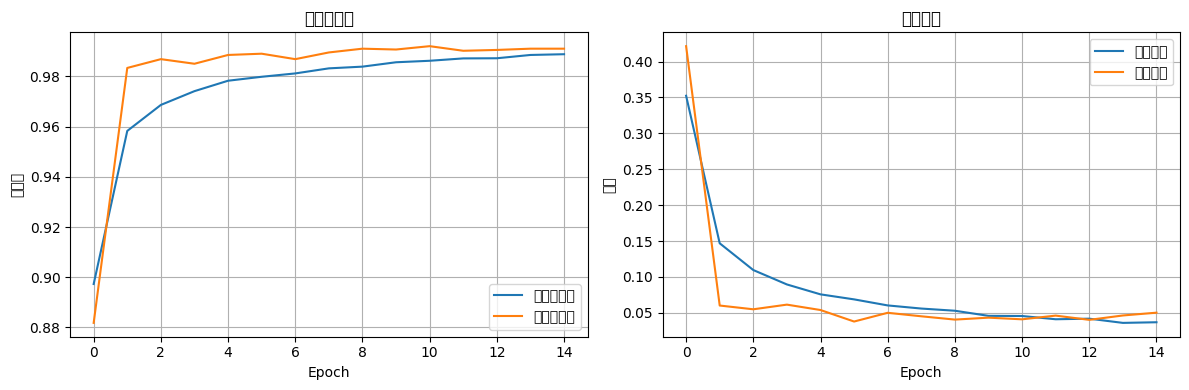

In [77]:
# 繪製訓練過程 （AI做）
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='訓練準確率')
plt.plot(history.history['val_accuracy'], label='驗證準確率')
plt.title('模型準確率')
plt.ylabel('準確率')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='訓練損失')
plt.plot(history.history['val_loss'], label='驗證損失')
plt.title('模型損失')
plt.ylabel('損失')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [78]:
# 顯示最佳驗證準確率
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
print(f"最佳驗證準確率: {best_val_acc:.4f} (第{best_epoch}輪)")

最佳驗證準確率: 0.9920 (第11輪)


In [79]:
loss, acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9916 - loss: 0.0338


In [80]:
print(f"測試資料正確率 {acc*100:.2f}%")

測試資料正確率 99.16%


In [81]:
predict = np.argmax(model.predict(x_test), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [82]:
predict

array([7, 2, 1, ..., 4, 5, 6])

In [83]:
# 整型回 28x28 的矩陣
def test(測試編號):
    plt.imshow(x_test[測試編號].reshape(28,28), cmap='Greys')
    print('神經網路判斷為:', predict[測試編號])

In [84]:
interact_manual(test, 測試編號=(0, 9999));

interactive(children=(IntSlider(value=4999, description='測試編號', max=9999), Button(description='Run Interact', …

給神經網路「總評量」。

In [85]:
score = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9916 - loss: 0.0338


In [86]:
print('loss:', score[0])
print('正確率', score[1])

loss: 0.0338456854224205
正確率 0.991599977016449


### 7. 用 Gradio 來展示

In [87]:
import cv2
import numpy as np

def resize_image(inp):
    # 取得畫布影像
    image = np.array(inp["layers"][0], dtype=np.uint8)

    # 提取 Alpha 通道（透明度），這代表我們畫的筆跡
    alpha_channel = image[:, :, 3]

    # 找出有筆跡的邊界框 (Bounding Box)
    coords = cv2.findNonZero(alpha_channel)
    if coords is None:
        # 如果什麼都沒畫，回傳全黑圖片
        return np.zeros((1, 28, 28, 1), dtype=np.float32)

    x, y, w, h = cv2.boundingRect(coords)

    # 裁切出數字部分 (去白邊)
    digit = alpha_channel[y:y+h, x:x+w]

    # 計算縮放比例，讓數字最大邊剛好是 20 像素 (還原 MNIST 資料集的 4 像素留白特色)
    target_size = 20
    scale = target_size / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    digit_resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # 建立一張 28x28 的全黑背景
    canvas = np.zeros((28, 28), dtype=np.uint8)

    # 將縮放後的數字貼到 28x28 的正中央
    y_offset = (28 - new_h) // 2
    x_offset = (28 - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit_resized

    # 轉成模型需要的形狀 (1, 28, 28, 1) 並正規化
    img_array = canvas.reshape(1, 28, 28, 1) / 255.0

    return img_array

In [88]:
def recognize_digit(inp):
    img_array = resize_image(inp)
    prediction = model.predict(img_array).flatten()
    labels = list('0123456789')
    return {labels[i]: float(prediction[i]) for i in range(10)}

In [ ]:
iface = gr.Interface(
    fn=recognize_digit,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=5),  # 顯示前5名結果
    title="個人5層CNN手寫辨識系統",
    description=f"使用5層深度神經網路 | 驗證準確率: {best_val_acc:.3f} | 測試準確率: {acc:.3f} | 參數數: {total_params:,}"
)

iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c63fbcb6ec96b00846.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
